# Audit Integritas Atribusi SHAP pada Prediksi IHSG

Notebook Python ini dirancang untuk **Kaggle.com/code**. Program mengunduh data IHSG otomatis dari Yahoo Finance melalui `yfinance`, membangun model prediksi imbal hasil satu hari ke depan, membuat atribusi Linear SHAP yang eksak, menyuntikkan bug secara sengaja, lalu memperbaiki skala dan sumbu tensor sebelum menerbitkan *waterfall plot*.

> Cara menjalankan: unggah notebook ke Kaggle, aktifkan **Internet** pada pengaturan notebook, lalu pilih **Run All**. Program tidak memakai data sintetis sebagai pengganti tersembunyi. Jika unduhan gagal, proses dihentikan agar integritas audit tetap terjaga.

**Tujuan audit**

1. Memastikan prediksi, *base value*, dan SHAP berada pada skala yang sama.
2. Menjaga urutan tensor `(sampel, waktu, fitur, horizon)`.
3. Menghitung residual dan persentase error aditivitas.
4. Memblokir visualisasi lokal jika toleransi numerik tidak terpenuhi.
5. Menghasilkan tabel dan gambar pada akhir setiap tahap.

Sumber utama: [dokumentasi yfinance](https://ranaroussi.github.io/yfinance/), [dokumentasi SHAP TreeExplainer](https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html), dan [Federal Reserve SR 26-2 (2026)](https://www.federalreserve.gov/supervisionreg/srletters/SR2602.htm). SR 26-2 menggantikan SR 11-7 sejak 17 April 2026. Notebook ini untuk pembelajaran dan audit teknis, bukan rekomendasi investasi.

## Algoritma Program

1. Tetapkan ticker IHSG `^JKSE`, periode data, panjang jendela, horizon, dan toleransi audit.
2. Unduh OHLCV harian secara otomatis dari Yahoo Finance. Tolak data kosong, kolom tidak lengkap, duplikasi tanggal, dan urutan waktu yang salah.
3. Bentuk fitur yang hanya memakai informasi hingga waktu `t`: imbal hasil, rentang intrahari, perubahan volume, jarak terhadap MA-5, volatilitas 10 hari, dan RSI-14.
4. Tetapkan target sebagai imbal hasil log pada hari perdagangan berikutnya.
5. Susun tensor jendela dengan bentuk `(sampel, waktu, fitur)`, lalu tambahkan sumbu horizon secara eksplisit pada hasil atribusi.
6. Bagi data secara kronologis. Fit *scaler* hanya pada data latih untuk mencegah kebocoran informasi.
7. Latih Ridge Regression pada target yang dinormalisasi.
8. Hitung Linear SHAP eksak: `phi_j = beta_j × (x_j − E[X_j])`. Nilai dasar ialah prediksi model pada rata-rata data latih.
9. Simulasikan laporan salah dengan mencampur skala asli dan skala normalisasi serta merata-ratakan sumbu waktu.
10. Hitung `error % = |prediksi − rekonstruksi| / max(|prediksi|, epsilon) × 100`.
11. Perbaiki kode dengan transformasi balik yang konsisten dan agregasi hanya pada sumbu waktu serta fitur.
12. Terbitkan tabel rekonstruksi dan *waterfall plot* hanya jika seluruh sampel lolos `np.isclose` dengan `atol` dan `rtol` yang ditetapkan.

## Pseudocode Program

```text
MULAI
  atur ticker, periode, lookback, horizon, seed, atol, rtol
  unduh data IHSG dari Yahoo Finance
  JIKA data kosong ATAU struktur kolom salah: HENTIKAN
  audit tanggal, duplikasi, missing value, dan OHLCV
  hitung fitur tanpa memakai informasi masa depan
  target <- log_return pada t+1
  buat X[sampel, waktu, fitur] dan y[sampel, horizon]
  split kronologis menjadi train dan test
  fit scaler_X dan scaler_y hanya pada train
  fit model Ridge pada target ternormalisasi
  prediksi_scaled <- model(X_test_scaled)
  base_scaled <- model(mean_background)
  SHAP_scaled <- koefisien * (X_test_scaled - mean_background)

  # Demonstrasi bug
  rekonstruksi_salah <- base_asli + SUM(MEAN_TIME(SHAP_scaled))
  error_salah <- hitung_error_persen(prediksi_asli, rekonstruksi_salah)

  # Perbaikan
  base_asli <- inverse_target(base_scaled)
  SHAP_asli <- SHAP_scaled * skala_target
  rekonstruksi_benar <- base_asli + SUM_TIME_FEATURE(SHAP_asli)
  residual <- prediksi_asli - rekonstruksi_benar
  error_benar <- hitung_error_persen(prediksi_asli, rekonstruksi_benar)
  audit_lolos <- IS_CLOSE(prediksi_asli, rekonstruksi_benar, atol, rtol)

  tampilkan tabel audit dan grafik residual
  JIKA semua audit_lolos:
      tampilkan waterfall plot dan ringkasan SHAP temporal
  SELAIN ITU:
      blokir waterfall plot dan laporkan sampel gagal
  simpan data, tabel audit, model metadata, dan gambar
SELESAI
```

In [7]:
# Tahap 0A: Instalasi dependensi yang belum tersedia di Kaggle
import importlib.util, subprocess, sys

paket = {"yfinance": "yfinance==1.5.2"}
for modul, spesifikasi in paket.items():
    if importlib.util.find_spec(modul) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", spesifikasi])

import pandas as pd
pd.DataFrame({"Komponen": list(paket), "Status": ["Siap"] * len(paket)})

,Komponen,Status
0,yfinance,Siap


In [8]:
# Tahap 0B: Konfigurasi audit dan gaya visual
from pathlib import Path
from datetime import date, timedelta
import json, math, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Markdown
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import yfinance as yf

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = 42
np.random.seed(SEED)
TICKER = "^JKSE"
START_DATE = "2015-01-01"
END_DATE = (date.today() + timedelta(days=1)).isoformat()
LOOKBACK = 10
HORIZON = 1
TRAIN_RATIO = 0.80
RIDGE_ALPHA = 10.0
ATOL = 1e-10
RTOL = 1e-7
EPSILON = 1e-12
OUTPUT_DIR = Path("/kaggle/working/ihsg_audit_outputs") if Path("/kaggle/working").exists() else Path("ihsg_audit_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (12, 5.5), "figure.dpi": 120,
    "axes.titlesize": 15, "axes.labelsize": 11,
    "font.size": 10, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.20
})
WARNA = {"utama": "#173B57", "positif": "#D95F59", "negatif": "#2D7FB8", "aman": "#2A9D8F", "peringatan": "#E9A23B"}

config_table = pd.DataFrame({
    "Parameter": ["Ticker", "Periode awal", "Periode akhir dinamis", "Lookback", "Horizon", "Split train", "ATOL", "RTOL"],
    "Nilai": [TICKER, START_DATE, END_DATE, LOOKBACK, HORIZON, f"{TRAIN_RATIO:.0%}", ATOL, RTOL]
})
display(Markdown("### Output Tahap 0: Konfigurasi"), config_table)

### Output Tahap 0: Konfigurasi

,Parameter,Nilai
0,Ticker,^JKSE
1,Periode awal,2015-01-01
2,Periode akhir dinamis,2026-08-03
3,Lookback,10
4,Horizon,1
5,Split train,80%
6,ATOL,0.0
7,RTOL,0.0


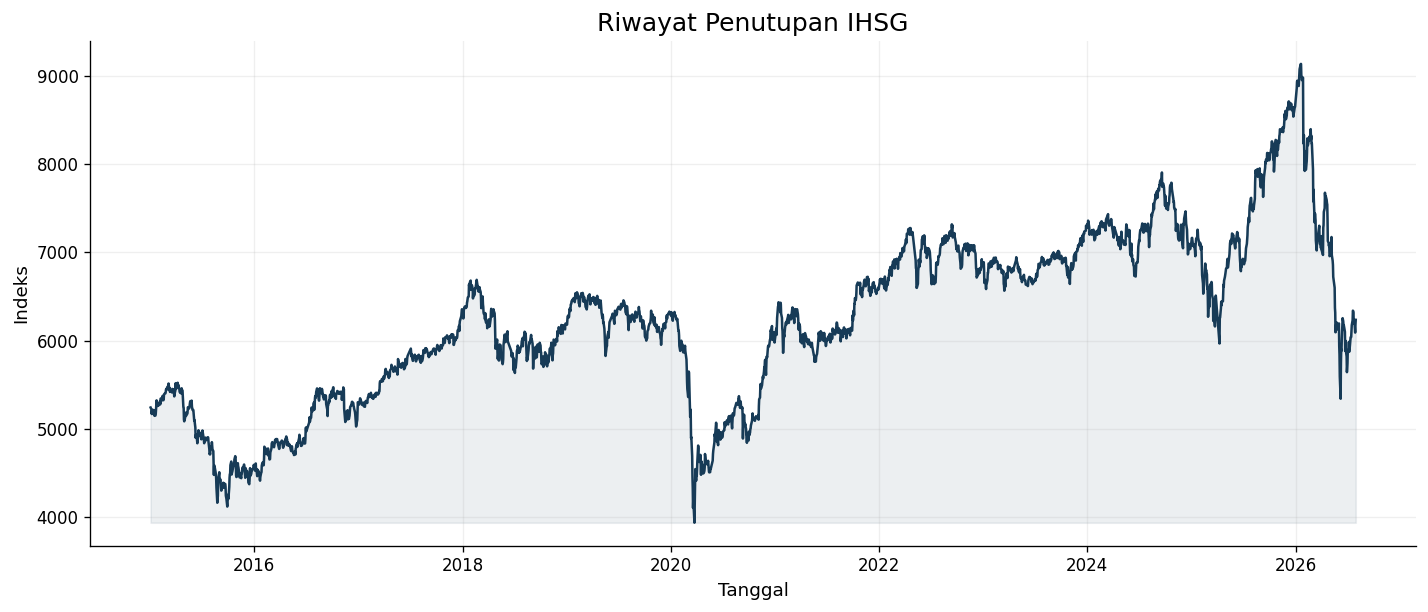

### Output Tahap 1: Audit Sumber Data

,Pemeriksaan,Hasil
0,Sumber,Yahoo Finance via yfinance
1,Ticker,^JKSE
2,Baris,2796
3,Tanggal awal,2015-01-02
4,Tanggal akhir,2026-07-31
5,Percobaan unduh,1
6,Duplikasi tanggal,0
7,Urutan kronologis,True


,Date,Open,High,Low,Close,Volume
2791,2026-07-27,6185.798828,6219.417969,6144.273926,6185.783203,241884600
2792,2026-07-28,6175.198242,6199.439941,6130.587891,6130.587891,198014300
2793,2026-07-29,6141.162109,6174.413086,6029.324219,6091.386230,288519700
2794,2026-07-30,6110.283203,6186.362793,6106.545898,6186.362793,231176100
2795,2026-07-31,6219.623047,6236.615234,6201.894043,6236.125977,274629600


In [9]:
# Tahap 1: Unduh otomatis data IHSG dan audit sumber
def download_ihsg(ticker, start, end, max_attempts=3):
    last_error = None
    for attempt in range(1, max_attempts + 1):
        try:
            try:
                df = yf.download(ticker, start=start, end=end, interval="1d", auto_adjust=False,
                                 actions=False, progress=False, threads=False, multi_level_index=False)
            except TypeError:
                df = yf.download(ticker, start=start, end=end, interval="1d", auto_adjust=False,
                                 actions=False, progress=False, threads=False)
            if df is not None and not df.empty:
                return df.copy(), attempt
            last_error = RuntimeError("Server mengembalikan data kosong.")
        except Exception as exc:
            last_error = exc
        time.sleep(2 * attempt)
    raise RuntimeError(
        "Unduhan IHSG gagal setelah tiga percobaan. Pastikan Internet Kaggle aktif. "
        "Program dihentikan agar tidak mengganti data pasar dengan data sintetis."
    ) from last_error

raw, attempts_used = download_ihsg(TICKER, START_DATE, END_DATE)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = [c[0] for c in raw.columns]
raw = raw.reset_index()
raw.columns = [str(c).strip() for c in raw.columns]
date_candidates = [c for c in raw.columns if c.lower() in {"date", "datetime", "index"}]
if not date_candidates:
    raise ValueError(f"Kolom tanggal tidak ditemukan. Kolom tersedia: {list(raw.columns)}")
raw = raw.rename(columns={date_candidates[0]: "Date"})
canonical = {c.lower(): c for c in raw.columns}
required_lower = ["open", "high", "low", "close", "volume"]
missing_required = [c for c in required_lower if c not in canonical]
if missing_required:
    raise ValueError(f"Kolom wajib hilang: {missing_required}")
raw = raw.rename(columns={canonical[c]: c.title() for c in required_lower})
raw["Date"] = pd.to_datetime(raw["Date"])
if getattr(raw["Date"].dt, "tz", None) is not None:
    raw["Date"] = raw["Date"].dt.tz_convert(None)
raw = raw[["Date", "Open", "High", "Low", "Close", "Volume"]].sort_values("Date").reset_index(drop=True)
raw.to_csv(OUTPUT_DIR / "ihsg_raw_yahoo_finance.csv", index=False)

source_audit = pd.DataFrame({
    "Pemeriksaan": ["Sumber", "Ticker", "Baris", "Tanggal awal", "Tanggal akhir", "Percobaan unduh", "Duplikasi tanggal", "Urutan kronologis"],
    "Hasil": ["Yahoo Finance via yfinance", TICKER, len(raw), raw.Date.min().date(), raw.Date.max().date(), attempts_used, int(raw.Date.duplicated().sum()), raw.Date.is_monotonic_increasing]
})

fig, ax = plt.subplots(figsize=(12, 5.2))
ax.plot(raw["Date"], raw["Close"], color=WARNA["utama"], linewidth=1.5)
ax.fill_between(raw["Date"], raw["Close"], raw["Close"].min(), color=WARNA["utama"], alpha=0.08)
ax.set(title="Riwayat Penutupan IHSG", xlabel="Tanggal", ylabel="Indeks")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_riwayat_ihsg.png", bbox_inches="tight")
plt.show()
display(Markdown("### Output Tahap 1: Audit Sumber Data"), source_audit, raw.tail(5))

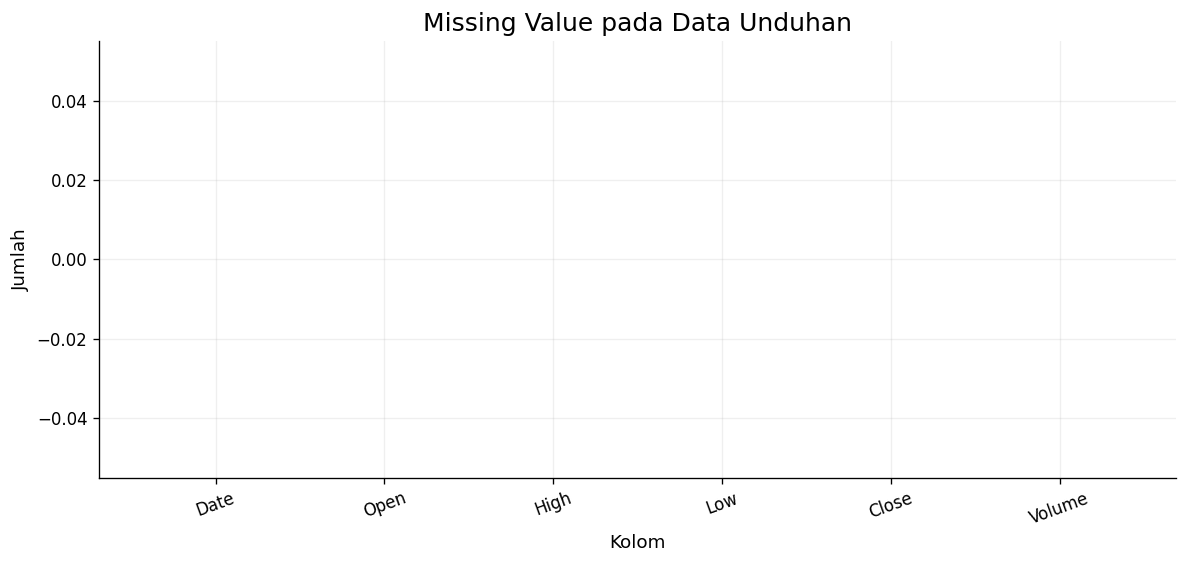

### Output Tahap 2: Kualitas dan Fitur

,Kolom,Missing,Tipe
0,Date,0,datetime64[ns]
1,Open,0,float64
2,High,0,float64
3,Low,0,float64
4,Close,0,float64
5,Volume,0,int64


,Fitur,Missing setelah cleaning,Minimum,Maksimum
0,Return_%,0,-8.2318,9.7042
1,Range_%,0,0.0000,10.0197
2,Volume_Change_%,0,-1930.6609,1919.4479
3,MA5_Gap_%,0,-8.7322,8.1940
4,Volatility_10_%,0,0.2290,5.0345
5,RSI_14,0,5.2549,96.0412
6,Target_Return_t+1_%,0,-8.2318,9.7042


,Date,Target_Date,Return_%,Range_%,Volume_Change_%,MA5_Gap_%,Volatility_10_%,RSI_14,Target_Return_t+1_%
2776,2026-07-24,2026-07-27,-1.900366,1.765358,-54.713207,-1.387313,1.129160,67.659604,-0.171972
2777,2026-07-27,2026-07-28,-0.171972,1.214786,-31.116449,-1.412419,1.018417,63.575169,-0.896298
2778,2026-07-28,2026-07-29,-0.896298,1.123091,-20.012150,-1.635451,1.080079,69.022585,-0.641497
2779,2026-07-29,2026-07-30,-0.641497,2.381869,37.642412,-1.496038,1.108886,63.231380,1.547164
2780,2026-07-30,2026-07-31,1.547164,1.290207,-22.158361,0.458789,1.163151,67.253596,0.801183


In [10]:
# Tahap 2: Pemeriksaan kualitas dan rekayasa fitur tanpa kebocoran masa depan
quality_before = pd.DataFrame({
    "Kolom": raw.columns,
    "Missing": [int(raw[c].isna().sum()) for c in raw.columns],
    "Tipe": [str(raw[c].dtype) for c in raw.columns]
})
if raw["Date"].duplicated().any():
    raise ValueError("Tanggal duplikat ditemukan. Audit dihentikan.")
if not raw["Date"].is_monotonic_increasing:
    raise ValueError("Urutan tanggal tidak kronologis. Audit dihentikan.")
if (raw[["Open", "High", "Low", "Close"]] <= 0).any().any():
    raise ValueError("Harga nol atau negatif ditemukan.")

df = raw.copy()
df["Return_%"] = np.log(df["Close"]).diff() * 100
df["Range_%"] = (df["High"] - df["Low"]) / df["Close"] * 100
df["Volume_Change_%"] = np.log1p(df["Volume"]).diff() * 100
df["MA5_Gap_%"] = (df["Close"] / df["Close"].rolling(5).mean() - 1) * 100
df["Volatility_10_%"] = df["Return_%"].rolling(10).std()
delta = df["Close"].diff()
avg_gain = delta.clip(lower=0).rolling(14).mean()
avg_loss = (-delta.clip(upper=0)).rolling(14).mean()
rs = avg_gain / avg_loss.replace(0, np.nan)
df["RSI_14"] = 100 - (100 / (1 + rs))
df["Target_Return_t+1_%"] = df["Return_%"].shift(-1)
df["Target_Date"] = df["Date"].shift(-1)

FEATURES = ["Return_%", "Range_%", "Volume_Change_%", "MA5_Gap_%", "Volatility_10_%", "RSI_14"]
FEATURE_LABELS = {
    "Return_%": "Imbal hasil", "Range_%": "Rentang intrahari",
    "Volume_Change_%": "Perubahan volume", "MA5_Gap_%": "Deviasi MA-5",
    "Volatility_10_%": "Volatilitas 10 hari", "RSI_14": "RSI 14"
}
TARGET = "Target_Return_t+1_%"
model_df = df[["Date", "Target_Date"] + FEATURES + [TARGET]].replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
model_df.to_csv(OUTPUT_DIR / "ihsg_features_clean.csv", index=False)

feature_audit = pd.DataFrame({
    "Fitur": FEATURES + [TARGET],
    "Missing setelah cleaning": [int(model_df[c].isna().sum()) for c in FEATURES + [TARGET]],
    "Minimum": [model_df[c].min() for c in FEATURES + [TARGET]],
    "Maksimum": [model_df[c].max() for c in FEATURES + [TARGET]],
})

fig, ax = plt.subplots(figsize=(10, 4.8))
missing_counts = quality_before.set_index("Kolom")["Missing"]
ax.bar(missing_counts.index, missing_counts.values, color=WARNA["peringatan"])
ax.set(title="Missing Value pada Data Unduhan", xlabel="Kolom", ylabel="Jumlah")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "02_missing_value.png", bbox_inches="tight")
plt.show()
display(Markdown("### Output Tahap 2: Kualitas dan Fitur"), quality_before, feature_audit.round(4), model_df.tail(5))

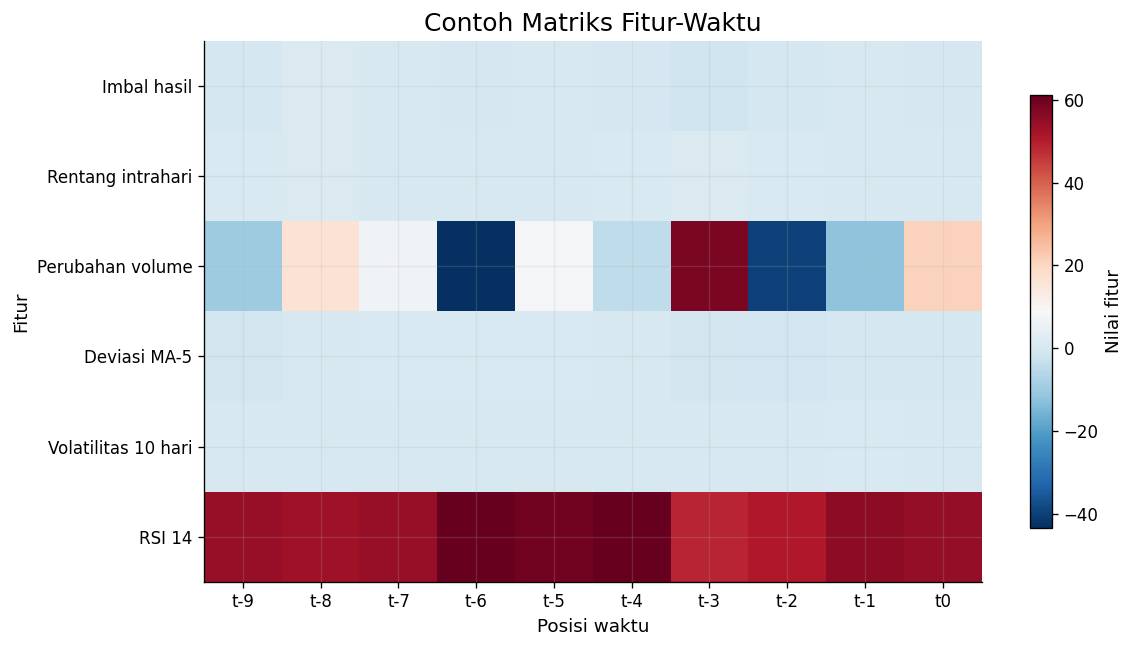

### Output Tahap 3: Tensor dan Split

,Objek,Shape,Makna
0,X seluruh,"(2772, 10, 6)","(sampel, waktu, fitur)"
1,y seluruh,"(2772, 1)","(sampel, horizon)"
2,X train,"(2217, 10, 6)",Tanpa shuffle
3,X test,"(555, 10, 6)",Periode terbaru


,Return_%,Range_%,Volume_Change_%,MA5_Gap_%,Volatility_10_%,RSI_14
t-9,-0.4033,0.9260,-9.5138,-0.6676,0.3308,54.5410
t-8,1.1297,1.1263,16.5337,0.4577,0.5228,53.2813
t-7,0.6007,0.7129,6.9765,0.9030,0.5567,54.6175
t-6,0.1077,0.5456,-43.4052,0.8185,0.5069,61.0623
t-5,0.5310,0.6684,7.6689,0.9569,0.5122,59.3085
t-4,0.1630,0.9928,-4.5536,0.6128,0.5090,61.1783
t-3,-1.4262,1.4779,58.3086,-0.8072,0.7007,48.7755
t-2,-0.3500,0.7889,-39.8914,-0.9621,0.7078,50.8099
t-1,0.4686,0.6454,-12.1271,-0.3749,0.7239,55.5474
t0,-0.0766,0.6562,20.9908,-0.2070,0.7029,54.7608


In [11]:
# Tahap 3: Pembentukan tensor dan split kronologis
def make_windows(frame, feature_cols, target_col, lookback):
    values = frame[feature_cols].to_numpy(dtype=float)
    targets = frame[target_col].to_numpy(dtype=float)
    target_dates = frame["Target_Date"].to_numpy()
    X, y, dates = [], [], []
    for end in range(lookback - 1, len(frame)):
        start = end - lookback + 1
        X.append(values[start:end + 1])
        y.append([targets[end]])
        dates.append(target_dates[end])
    return np.asarray(X), np.asarray(y), pd.to_datetime(dates)

X, y, target_dates = make_windows(model_df, FEATURES, TARGET, LOOKBACK)
assert X.ndim == 3 and y.shape[1] == HORIZON
split_idx = int(len(X) * TRAIN_RATIO)
if split_idx <= 0 or split_idx >= len(X):
    raise ValueError("Split train-test tidak valid.")
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_train, dates_test = target_dates[:split_idx], target_dates[split_idx:]

shape_audit = pd.DataFrame([
    ["X seluruh", str(X.shape), "(sampel, waktu, fitur)"],
    ["y seluruh", str(y.shape), "(sampel, horizon)"],
    ["X train", str(X_train.shape), "Tanpa shuffle"],
    ["X test", str(X_test.shape), "Periode terbaru"],
], columns=["Objek", "Shape", "Makna"])

sample_matrix = pd.DataFrame(X_train[-1], columns=FEATURES, index=[f"t-{LOOKBACK-1-i}" if i < LOOKBACK-1 else "t0" for i in range(LOOKBACK)])
fig, ax = plt.subplots(figsize=(10, 5.5))
im = ax.imshow(sample_matrix.T, aspect="auto", cmap="RdBu_r")
ax.set_yticks(range(len(FEATURES)), labels=[FEATURE_LABELS[f] for f in FEATURES])
ax.set_xticks(range(LOOKBACK), labels=sample_matrix.index)
ax.set(title="Contoh Matriks Fitur-Waktu", xlabel="Posisi waktu", ylabel="Fitur")
fig.colorbar(im, ax=ax, shrink=0.8, label="Nilai fitur")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "03_tensor_fitur_waktu.png", bbox_inches="tight")
plt.show()
display(Markdown("### Output Tahap 3: Tensor dan Split"), shape_audit, sample_matrix.round(4))

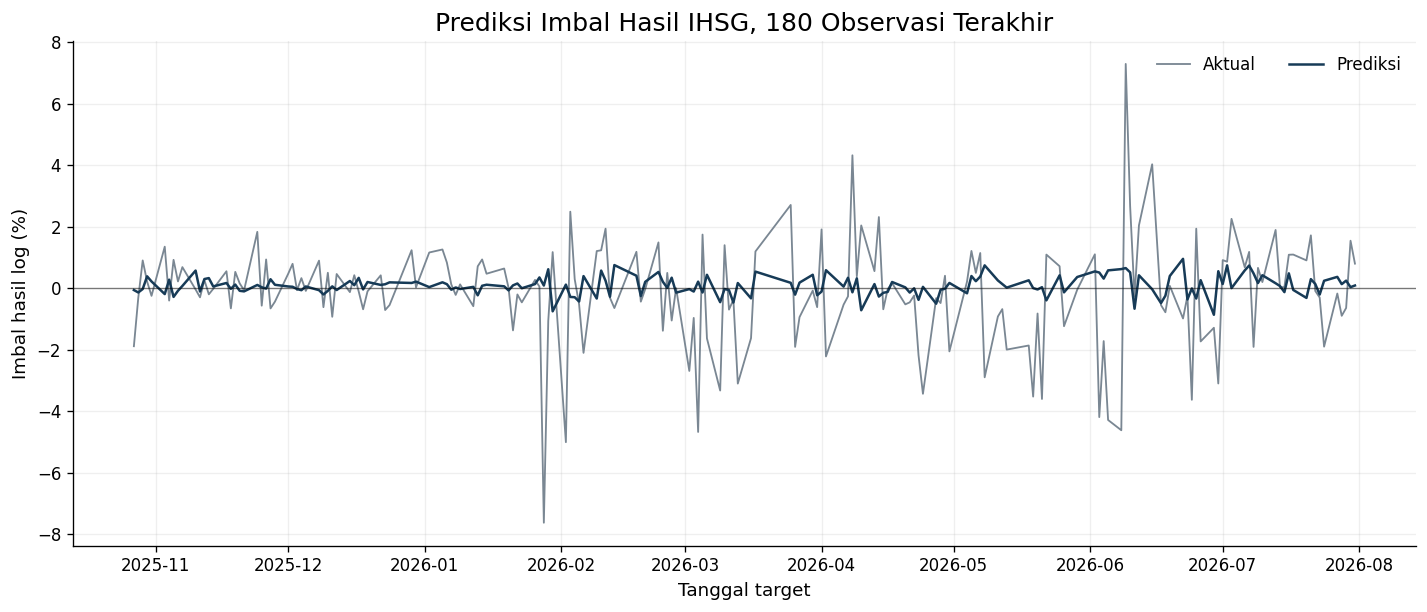

### Output Tahap 4: Kinerja Model

,Metrik,Nilai,Satuan
0,MAE,0.961201,poin persentase
1,RMSE,1.383345,poin persentase
2,R²,-0.047341,rasio
3,Akurasi arah,0.502703,proporsi


,Tanggal,Aktual_%,Prediksi_%
0,2026-07-27,-0.171972,0.370244
1,2026-07-28,-0.896298,0.133475
2,2026-07-29,-0.641497,0.248182
3,2026-07-30,1.547164,0.036665
4,2026-07-31,0.801183,0.089425


In [12]:
# Tahap 4: Normalisasi berbasis train, pelatihan, dan evaluasi prediksi
n_features = len(FEATURES)
X_train_flat = X_train.reshape(len(X_train), LOOKBACK * n_features)
X_test_flat = X_test.reshape(len(X_test), LOOKBACK * n_features)
x_scaler = StandardScaler().fit(X_train_flat)
y_scaler = StandardScaler().fit(y_train)
X_train_s = x_scaler.transform(X_train_flat)
X_test_s = x_scaler.transform(X_test_flat)
y_train_s = y_scaler.transform(y_train).ravel()

model = Ridge(alpha=RIDGE_ALPHA, fit_intercept=True)
model.fit(X_train_s, y_train_s)
pred_scaled = model.predict(X_test_s)
pred_original = y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
actual_original = y_test.ravel()

metrics = pd.DataFrame({
    "Metrik": ["MAE", "RMSE", "R²", "Akurasi arah"],
    "Nilai": [
        mean_absolute_error(actual_original, pred_original),
        np.sqrt(mean_squared_error(actual_original, pred_original)),
        r2_score(actual_original, pred_original),
        np.mean(np.sign(actual_original) == np.sign(pred_original))
    ],
    "Satuan": ["poin persentase", "poin persentase", "rasio", "proporsi"]
})

plot_n = min(180, len(dates_test))
fig, ax = plt.subplots(figsize=(12, 5.2))
ax.plot(dates_test[-plot_n:], actual_original[-plot_n:], color="#7A8793", linewidth=1.1, label="Aktual")
ax.plot(dates_test[-plot_n:], pred_original[-plot_n:], color=WARNA["utama"], linewidth=1.5, label="Prediksi")
ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set(title=f"Prediksi Imbal Hasil IHSG, {plot_n} Observasi Terakhir", xlabel="Tanggal target", ylabel="Imbal hasil log (%)")
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "04_prediksi_vs_aktual.png", bbox_inches="tight")
plt.show()
display(Markdown("### Output Tahap 4: Kinerja Model"), metrics.round(6), pd.DataFrame({"Tanggal": dates_test[-5:], "Aktual_%": actual_original[-5:], "Prediksi_%": pred_original[-5:]}).round(6))

## Dasar Matematis Linear SHAP

Ridge Regression dipilih agar mekanisme audit dapat diperiksa secara eksak. Pada model linear `f(x) = b + Σ βⱼxⱼ` dengan *background* rata-rata data latih, kontribusi intervensional setiap pemain ialah `φⱼ = βⱼ(xⱼ − E[Xⱼ])`. Nilai dasarnya `E[f(X)] = b + Σ βⱼE[Xⱼ]`. Maka `base value + Σφⱼ = f(x)` hingga toleransi aritmetika *floating point*.

Pemain dalam notebook ini bukan sekadar enam fitur. Setiap pasangan fitur dan waktu menjadi pemain terpisah, misalnya `Return_% pada t-3`. Bentuk datar hanya dipakai saat model dilatih. Nilai atribusi dikembalikan ke tensor agar identitas waktu dan fitur tetap terjaga. Pendekatan ini menjelaskan keluaran model, bukan membuktikan penyebab ekonomi.

In [13]:
# Tahap 5: Hitung Linear SHAP eksak dan catat seluruh shape
background_mean = X_train_s.mean(axis=0)
base_scaled = float(model.intercept_ + np.dot(background_mean, model.coef_))
shap_flat_scaled = (X_test_s - background_mean) * model.coef_
shap_3d_scaled = shap_flat_scaled.reshape(len(X_test), LOOKBACK, n_features)
shap_4d_scaled = shap_3d_scaled[..., np.newaxis]

shape_shap = pd.DataFrame([
    ["X_test asli", str(X_test.shape), "(sampel, waktu, fitur)"],
    ["X_test model", str(X_test_s.shape), "(sampel, waktu×fitur)"],
    ["Prediksi", str(pred_scaled.shape), "(sampel,)"],
    ["SHAP datar", str(shap_flat_scaled.shape), "(sampel, waktu×fitur)"],
    ["SHAP tensor", str(shap_4d_scaled.shape), "(sampel, waktu, fitur, horizon)"],
    ["Base value", str(np.asarray(base_scaled).shape), "skalar untuk horizon 0"],
], columns=["Objek", "Shape", "Makna"])

quick_residual_scaled = pred_scaled - (base_scaled + shap_flat_scaled.sum(axis=1))
quick_check = pd.DataFrame({
    "Statistik": ["Residual maksimum skala model", "Jumlah horizon", "Jumlah fitur", "Jumlah time-step"],
    "Nilai": [np.max(np.abs(quick_residual_scaled)), HORIZON, n_features, LOOKBACK]
})
assert shap_4d_scaled.shape == (len(X_test), LOOKBACK, n_features, HORIZON)
display(Markdown("### Output Tahap 5: Jejak Shape SHAP"), shape_shap, quick_check)

### Output Tahap 5: Jejak Shape SHAP

,Objek,Shape,Makna
0,X_test asli,"(555, 10, 6)","(sampel, waktu, fitur)"
1,X_test model,"(555, 60)","(sampel, waktu×fitur)"
2,Prediksi,"(555,)","(sampel,)"
3,SHAP datar,"(555, 60)","(sampel, waktu×fitur)"
4,SHAP tensor,"(555, 10, 6, 1)","(sampel, waktu, fitur, horizon)"
5,Base value,(),skalar untuk horizon 0


,Statistik,Nilai
0,Residual maksimum skala model,7.771561e-16
1,Jumlah horizon,1.000000e+00
2,Jumlah fitur,6.000000e+00
3,Jumlah time-step,1.000000e+01


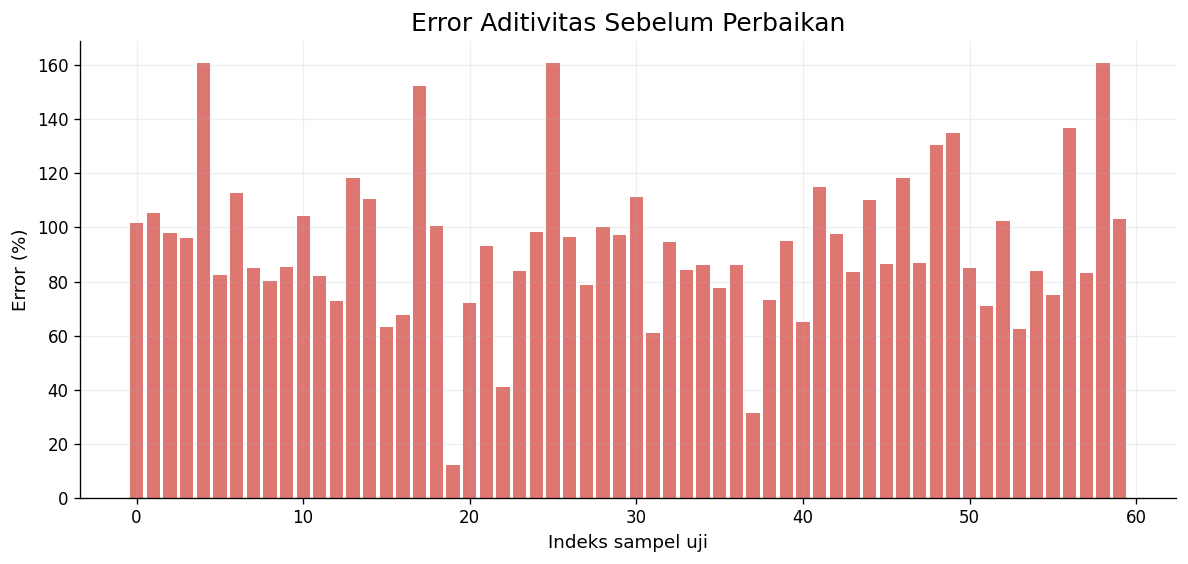

### Output Tahap 6: Bukti Bug

,Tanggal,Base_Value,Total_SHAP_Salah,Prediksi_Rekonstruksi,Prediksi_Asli,Selisih,Error_%,Status
0,2024-03-22,0.014548,-0.012637,0.001911,-0.107175,-0.109087,101.783246,GAGAL
1,2024-03-25,0.014548,-0.010209,0.004339,-0.083786,-0.088125,105.179171,GAGAL
2,2024-03-26,0.014548,-0.017653,-0.003105,-0.155495,-0.152390,98.003066,GAGAL
3,2024-03-27,0.014548,-0.022184,-0.007636,-0.199140,-0.191504,96.165455,GAGAL
4,2024-03-28,0.014548,-0.002600,0.011948,-0.010495,-0.022443,213.841064,GAGAL
5,2024-04-01,0.014548,0.017092,0.031640,0.179183,0.147543,82.342300,GAGAL
6,2024-04-02,0.014548,-0.007328,0.007220,-0.056039,-0.063259,112.883653,GAGAL
7,2024-04-03,0.014548,0.028107,0.042655,0.285286,0.242631,85.048440,GAGAL
8,2024-04-04,0.014548,0.013022,0.027570,0.139978,0.112409,80.304405,GAGAL
9,2024-04-05,0.014548,0.030728,0.045276,0.310532,0.265256,85.419980,GAGAL


,Status,Jumlah
0,GAGAL,555


In [14]:
# Tahap 6: Simulasi bug laporan, salah skala dan averaging waktu
target_mean = float(y_scaler.mean_[0])
target_scale = float(y_scaler.scale_[0])
base_original = base_scaled * target_scale + target_mean

# BUG 1: base sudah di skala asli, SHAP masih di skala normalisasi.
# BUG 2: sumbu waktu dirata-ratakan, bukan dijumlahkan.
bug_shap_total = shap_3d_scaled.mean(axis=1).sum(axis=1)
bug_reconstruction = base_original + bug_shap_total
bug_difference = pred_original - bug_reconstruction
bug_error_pct = np.abs(bug_difference) / np.maximum(np.abs(pred_original), EPSILON) * 100

bug_audit = pd.DataFrame({
    "Tanggal": dates_test,
    "Base_Value": base_original,
    "Total_SHAP_Salah": bug_shap_total,
    "Prediksi_Rekonstruksi": bug_reconstruction,
    "Prediksi_Asli": pred_original,
    "Selisih": bug_difference,
    "Error_%": bug_error_pct,
    "Status": np.where(np.isclose(pred_original, bug_reconstruction, atol=ATOL, rtol=RTOL), "LOLOS", "GAGAL")
})

bug_summary = bug_audit["Status"].value_counts().rename_axis("Status").reset_index(name="Jumlah")
fig, ax = plt.subplots(figsize=(10, 4.8))
show_n = min(60, len(bug_audit))
ax.bar(np.arange(show_n), np.clip(bug_error_pct[:show_n], 0, np.nanpercentile(bug_error_pct, 95)), color=WARNA["positif"], alpha=0.85)
ax.set(title="Error Aditivitas Sebelum Perbaikan", xlabel="Indeks sampel uji", ylabel="Error (%)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "05_error_sebelum_perbaikan.png", bbox_inches="tight")
plt.show()
display(Markdown("### Output Tahap 6: Bukti Bug"), bug_audit.head(10).round(8), bug_summary)

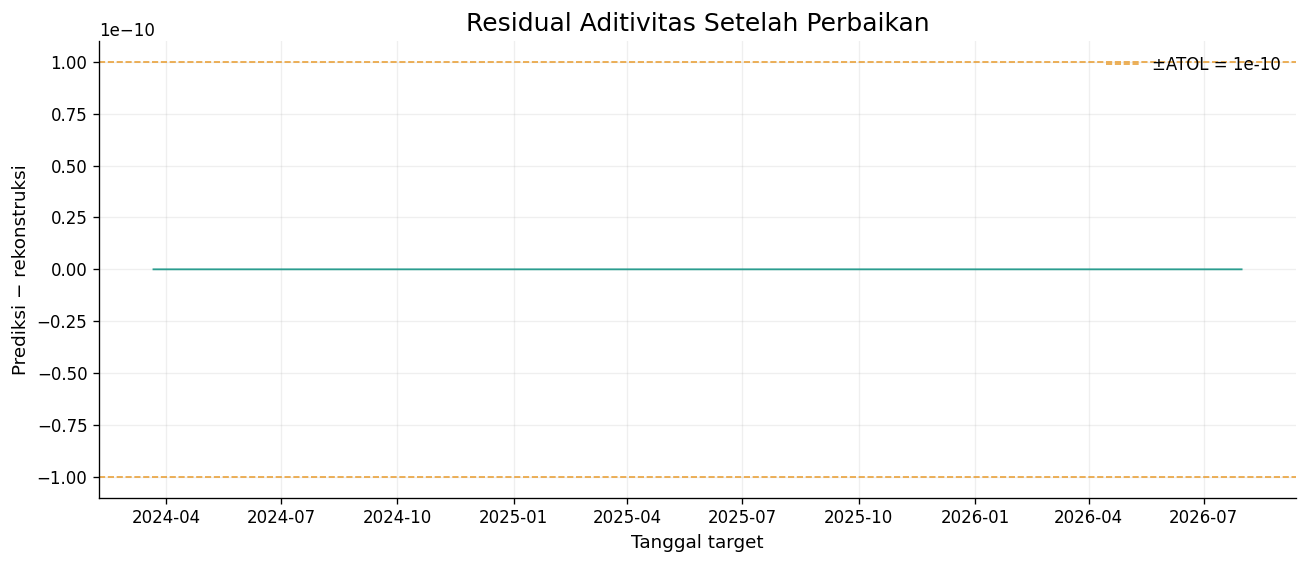

### Output Tahap 7: Tabel Rekonstruksi Final

,Tanggal,Horizon,Base_Value,Total_SHAP,Prediksi_Rekonstruksi,Prediksi_Asli,Selisih,Error_%,Status
0,2024-03-22,1,0.014548,-0.121723,-0.107175,-0.107175,-0.0,0.0,LOLOS
1,2024-03-25,1,0.014548,-0.098334,-0.083786,-0.083786,-0.0,0.0,LOLOS
2,2024-03-26,1,0.014548,-0.170043,-0.155495,-0.155495,-0.0,0.0,LOLOS
3,2024-03-27,1,0.014548,-0.213688,-0.199140,-0.199140,0.0,0.0,LOLOS
4,2024-03-28,1,0.014548,-0.025043,-0.010495,-0.010495,0.0,0.0,LOLOS
5,2024-04-01,1,0.014548,0.164635,0.179183,0.179183,-0.0,0.0,LOLOS
6,2024-04-02,1,0.014548,-0.070587,-0.056039,-0.056039,0.0,0.0,LOLOS
7,2024-04-03,1,0.014548,0.270738,0.285286,0.285286,-0.0,0.0,LOLOS
8,2024-04-04,1,0.014548,0.125430,0.139978,0.139978,0.0,0.0,LOLOS
9,2024-04-05,1,0.014548,0.295984,0.310532,0.310532,-0.0,0.0,LOLOS


,Indikator,Nilai
0,Sampel diuji,555
1,Sampel lolos,555
2,Residual absolut maksimum,0.0
3,Error maksimum (%),0.0
4,ATOL,0.0
5,RTOL,0.0
6,Keputusan,TERBITKAN WATERFALL


In [15]:
# Tahap 7: Perbaikan skala, agregasi tensor, dan audit aditivitas
def audit_additivity(prediction, base_value, shap_tensor, atol=1e-10, rtol=1e-7, epsilon=1e-12):
    if shap_tensor.ndim != 4:
        raise ValueError(f"SHAP harus 4D, ditemukan {shap_tensor.ndim}D dengan shape {shap_tensor.shape}")
    if shap_tensor.shape[0] != len(prediction):
        raise ValueError("Jumlah sampel SHAP tidak sama dengan jumlah prediksi.")
    horizon_idx = 0
    total_shap = shap_tensor[:, :, :, horizon_idx].sum(axis=(1, 2))
    reconstruction = base_value + total_shap
    difference = prediction - reconstruction
    denominator = np.maximum(np.abs(prediction), epsilon)
    error_pct = np.abs(difference) / denominator * 100
    passed = np.isclose(prediction, reconstruction, atol=atol, rtol=rtol)
    return total_shap, reconstruction, difference, error_pct, passed

# Transformasi balik affine yang benar:
# y_asli = y_scaled * scale + mean
# base_asli = base_scaled * scale + mean
# SHAP_asli = SHAP_scaled * scale, tanpa menambahkan mean ke setiap kontribusi.
shap_4d_original = shap_4d_scaled * target_scale
total_shap, reconstruction, difference, error_pct, passed = audit_additivity(
    pred_original, base_original, shap_4d_original, ATOL, RTOL, EPSILON
)
AUDIT_PASSED = bool(passed.all())

audit_table = pd.DataFrame({
    "Tanggal": dates_test,
    "Horizon": 1,
    "Base_Value": base_original,
    "Total_SHAP": total_shap,
    "Prediksi_Rekonstruksi": reconstruction,
    "Prediksi_Asli": pred_original,
    "Selisih": difference,
    "Error_%": error_pct,
    "Status": np.where(passed, "LOLOS", "GAGAL")
})
audit_table.to_csv(OUTPUT_DIR / "tabel_audit_aditivitas.csv", index=False)

audit_summary = pd.DataFrame({
    "Indikator": ["Sampel diuji", "Sampel lolos", "Residual absolut maksimum", "Error maksimum (%)", "ATOL", "RTOL", "Keputusan"],
    "Nilai": [len(passed), int(passed.sum()), np.max(np.abs(difference)), np.max(error_pct), ATOL, RTOL, "TERBITKAN WATERFALL" if AUDIT_PASSED else "BLOKIR WATERFALL"]
})

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(dates_test, difference, color=WARNA["aman"], linewidth=1.1)
ax.axhline(ATOL, color=WARNA["peringatan"], linestyle="--", linewidth=1, label=f"±ATOL = {ATOL:g}")
ax.axhline(-ATOL, color=WARNA["peringatan"], linestyle="--", linewidth=1)
ax.set(title="Residual Aditivitas Setelah Perbaikan", xlabel="Tanggal target", ylabel="Prediksi − rekonstruksi")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "06_residual_setelah_perbaikan.png", bbox_inches="tight")
plt.show()
display(Markdown("### Output Tahap 7: Tabel Rekonstruksi Final"), audit_table.head(10).round(12), audit_summary)

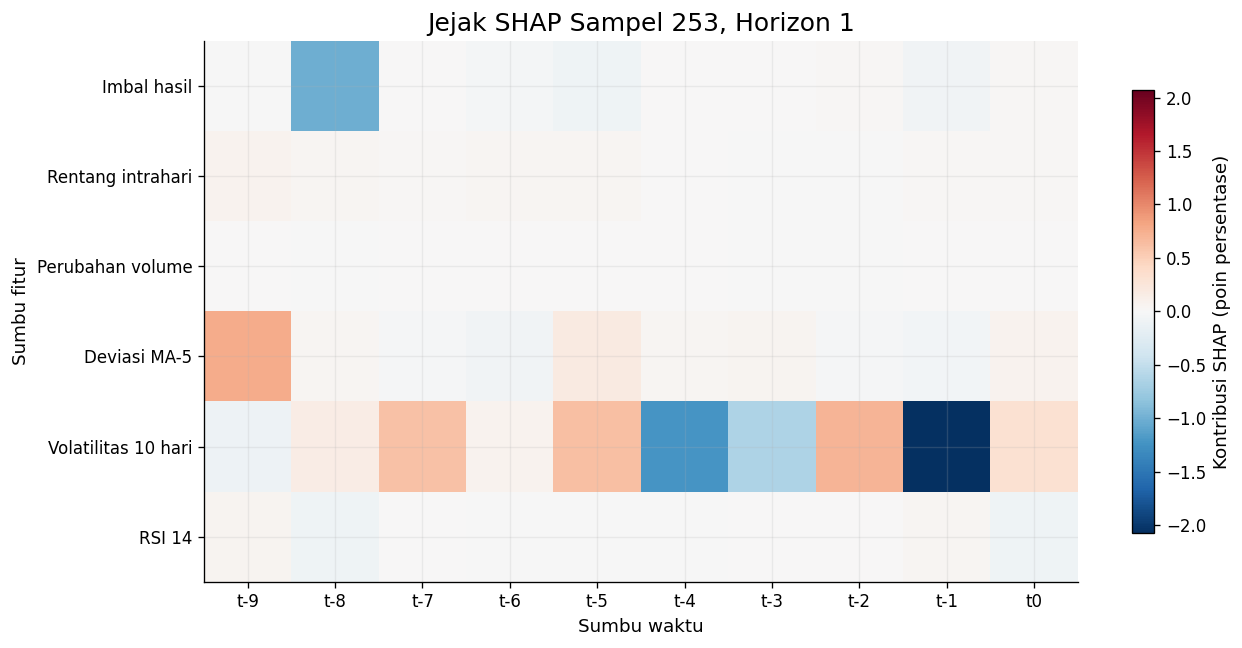

### Output Tahap 8: Kontrak Tensor

,Sumbu,Nama,Ukuran,Aturan audit
0,0,sampel,555,harus sama dengan prediksi
1,1,waktu,10,jangan dirata-ratakan
2,2,fitur,6,jumlahkan untuk rekonstruksi
3,3,horizon,1,pilih indeks secara eksplisit


,Komponen,Nilai
0,Jumlah tensor fitur-waktu,-1.511578
1,Total_SHAP pada tabel audit,-1.511578
2,Selisih kedua perhitungan,0.000000


,Return_%,Range_%,Volume_Change_%,MA5_Gap_%,Volatility_10_%,RSI_14
t-9,-0.005628,0.075090,0.008336,0.773724,-0.100392,0.060308
t-8,-1.016960,0.032710,-0.001677,0.039064,0.161856,-0.093881
t-7,0.004806,0.018256,0.003134,-0.024559,0.612880,0.003050
t-6,-0.037569,0.034894,0.002936,-0.066129,0.067782,-0.002842
t-5,-0.081503,0.038775,0.000085,0.188570,0.631389,-0.003117
t-4,0.004737,0.011333,0.000034,0.037734,-1.215332,-0.002556
t-3,0.007554,-0.015452,-0.001136,0.061063,-0.636772,0.004128
t-2,0.016908,-0.003403,-0.005917,-0.031355,0.696881,0.006618
t-1,-0.065557,0.022909,0.011815,-0.051647,-2.073351,0.033633
t0,0.022307,0.021325,0.004240,0.066856,0.320327,-0.082897


In [16]:
# Tahap 8: Audit semantik sumbu tensor dan pemilihan horizon eksplisit
horizon_idx = 0
time_labels = [f"t-{LOOKBACK-1-i}" if i < LOOKBACK-1 else "t0" for i in range(LOOKBACK)]
tensor_contract = pd.DataFrame({
    "Sumbu": [0, 1, 2, 3],
    "Nama": ["sampel", "waktu", "fitur", "horizon"],
    "Ukuran": list(shap_4d_original.shape),
    "Aturan audit": ["harus sama dengan prediksi", "jangan dirata-ratakan", "jumlahkan untuk rekonstruksi", "pilih indeks secara eksplisit"]
})

sample_i = int(np.argmax(np.abs(pred_original)))
cell_trace = pd.DataFrame(shap_4d_original[sample_i, :, :, horizon_idx], index=time_labels, columns=FEATURES)
axis_totals = pd.DataFrame({
    "Komponen": ["Jumlah tensor fitur-waktu", "Total_SHAP pada tabel audit", "Selisih kedua perhitungan"],
    "Nilai": [cell_trace.to_numpy().sum(), total_shap[sample_i], cell_trace.to_numpy().sum() - total_shap[sample_i]]
})

fig, ax = plt.subplots(figsize=(11, 5.5))
limit = np.max(np.abs(cell_trace.to_numpy())) or 1
im = ax.imshow(cell_trace.T, aspect="auto", cmap="RdBu_r", vmin=-limit, vmax=limit)
ax.set_yticks(range(n_features), labels=[FEATURE_LABELS[f] for f in FEATURES])
ax.set_xticks(range(LOOKBACK), labels=time_labels)
ax.set(title=f"Jejak SHAP Sampel {sample_i}, Horizon {horizon_idx + 1}", xlabel="Sumbu waktu", ylabel="Sumbu fitur")
fig.colorbar(im, ax=ax, shrink=0.82, label="Kontribusi SHAP (poin persentase)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "07_jejak_tensor_shap.png", bbox_inches="tight")
plt.show()
display(Markdown("### Output Tahap 8: Kontrak Tensor"), tensor_contract, axis_totals.round(12), cell_trace.round(6))

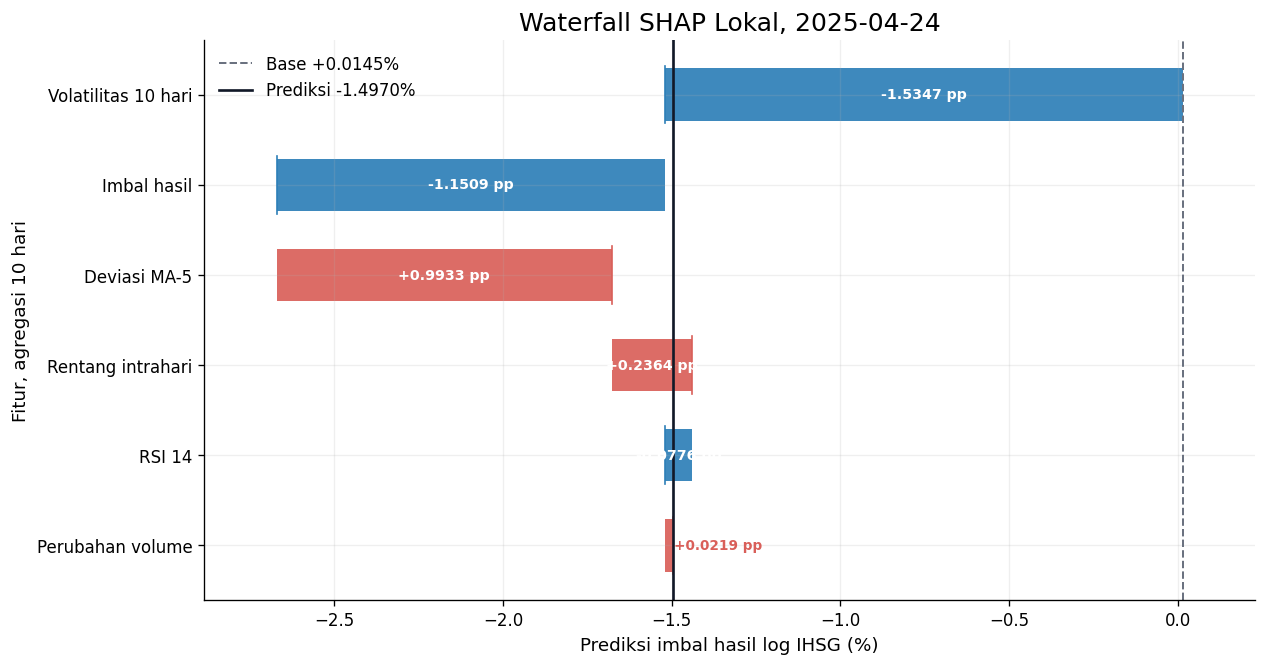

### Output Tahap 9: Waterfall Terkoreksi

,Peringkat,Fitur,Kode_Fitur,SHAP_pp
0,1,Volatilitas 10 hari,Volatility_10_%,-1.534732
1,2,Imbal hasil,Return_%,-1.150903
2,3,Deviasi MA-5,MA5_Gap_%,0.993322
3,4,Rentang intrahari,Range_%,0.236439
4,5,RSI 14,RSI_14,-0.077554
5,6,Perubahan volume,Volume_Change_%,0.021851


,Base_Value,Total_SHAP,Prediksi_Rekonstruksi,Prediksi_Asli,Status
0,0.014548,-1.511578,-1.49703,-1.49703,LOLOS


In [17]:
# Tahap 9: Waterfall plot lokal hanya setelah audit lolos
if not AUDIT_PASSED:
    failed_ids = np.flatnonzero(~passed)[:10].tolist()
    raise RuntimeError(f"Waterfall diblokir. Sampel gagal audit: {failed_ids}")

local_by_feature = shap_4d_original[sample_i, :, :, horizon_idx].sum(axis=0)
order = np.argsort(np.abs(local_by_feature))[::-1]
ordered_features = [FEATURES[i] for i in order]
ordered_feature_labels = [FEATURE_LABELS[f] for f in ordered_features]
ordered_values = local_by_feature[order]

running = base_original
starts, ends = [], []
for value in ordered_values:
    starts.append(running)
    running += value
    ends.append(running)

fig, ax = plt.subplots(figsize=(12, 6.3))
y_pos = np.arange(len(ordered_features))
for pos, (feature, value, start, end) in enumerate(zip(ordered_feature_labels, ordered_values, starts, ends)):
    left = min(start, end)
    width = abs(value)
    color = WARNA["positif"] if value >= 0 else WARNA["negatif"]
    ax.barh(pos, width, left=left, color=color, height=0.58, alpha=0.92)
    ax.plot([end, end], [pos - 0.32, pos + 0.32], color=color, linewidth=1)
    if width >= 0.055:
        ax.text((start + end) / 2, pos, f"{value:+.4f} pp", va="center", ha="center",
                fontsize=8.5, color="white", fontweight="bold")
    elif width >= 0.03:
        ax.text((start + end) / 2, pos, f"{value:+.3f}", va="center", ha="center",
                fontsize=8.0, color="white", fontweight="bold")
    else:
        label_x = end + (0.004 if value >= 0 else -0.004)
        ax.text(label_x, pos, f"{value:+.4f} pp", va="center",
                ha="left" if value >= 0 else "right", fontsize=8.2, color=color, fontweight="bold")
ax.axvline(base_original, color="#6B7280", linestyle="--", linewidth=1.2, label=f"Base {base_original:+.4f}%")
ax.axvline(pred_original[sample_i], color="#111827", linewidth=1.6, label=f"Prediksi {pred_original[sample_i]:+.4f}%")
x_min = min([base_original, pred_original[sample_i]] + starts + ends)
x_max = max([base_original, pred_original[sample_i]] + starts + ends)
x_pad = max((x_max - x_min) * 0.08, 0.01)
ax.set_xlim(x_min - x_pad, x_max + x_pad)
ax.set_yticks(y_pos, labels=ordered_feature_labels)
ax.invert_yaxis()
ax.set(title=f"Waterfall SHAP Lokal, {pd.Timestamp(dates_test[sample_i]).date()}", xlabel="Prediksi imbal hasil log IHSG (%)", ylabel="Fitur, agregasi 10 hari")
ax.legend(frameon=False, loc="best")
fig.subplots_adjust(left=0.24, right=0.97, bottom=0.16, top=0.90)
fig.savefig(OUTPUT_DIR / "08_waterfall_shap_lokal.png", bbox_inches="tight")
plt.show()

waterfall_table = pd.DataFrame({"Peringkat": np.arange(1, n_features + 1), "Fitur": ordered_feature_labels, "Kode_Fitur": ordered_features, "SHAP_pp": ordered_values})
waterfall_check = pd.DataFrame({
    "Base_Value": [base_original], "Total_SHAP": [ordered_values.sum()],
    "Prediksi_Rekonstruksi": [base_original + ordered_values.sum()],
    "Prediksi_Asli": [pred_original[sample_i]], "Status": ["LOLOS"]
})
display(Markdown("### Output Tahap 9: Waterfall Terkoreksi"), waterfall_table.round(6), waterfall_check.round(12))

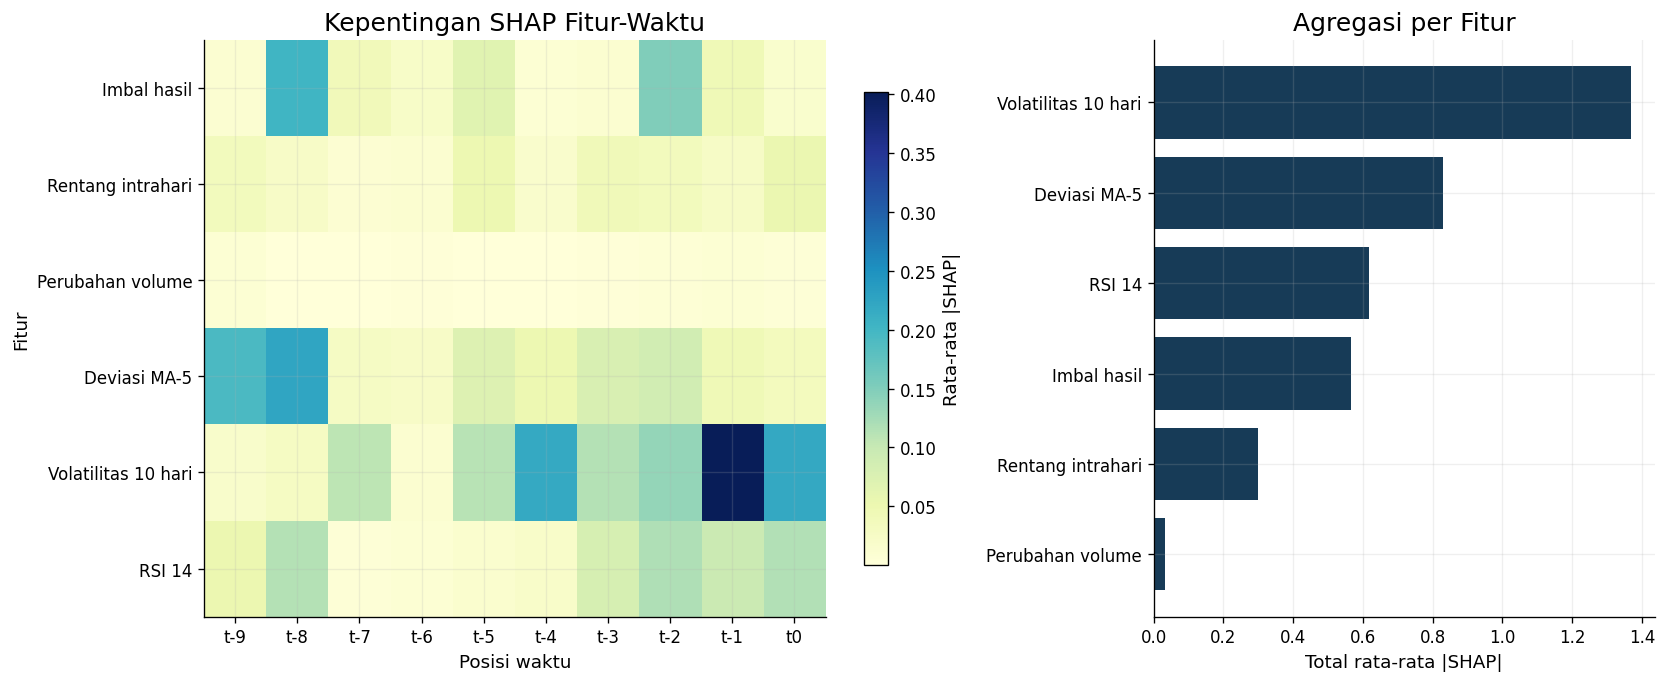

### Output Tahap 10: SHAP Global Temporal

,Waktu,Fitur,Mean_Abs_SHAP
0,t-1,Volatility_10_%,0.402175
1,t-8,MA5_Gap_%,0.224119
2,t0,Volatility_10_%,0.219449
3,t-4,Volatility_10_%,0.218061
4,t-8,Return_%,0.202037
5,t-9,MA5_Gap_%,0.192882
6,t-2,Return_%,0.149950
7,t-2,Volatility_10_%,0.136682
8,t-2,RSI_14,0.117351
9,t0,RSI_14,0.115004


,Waktu,Total_Mean_Abs_SHAP
0,t-1,0.614513
1,t-8,0.592758
2,t-2,0.533573
3,t0,0.438995
4,t-3,0.329503
5,t-9,0.316740
6,t-5,0.313349
7,t-4,0.310827
8,t-7,0.186343
9,t-6,0.077038


In [18]:
# Tahap 10: Analisis global tanpa menghapus urutan waktu
mean_abs_shap = np.mean(np.abs(shap_4d_original[:, :, :, horizon_idx]), axis=0)
global_matrix = pd.DataFrame(mean_abs_shap, index=time_labels, columns=FEATURES)
importance_feature = global_matrix.sum(axis=0).sort_values(ascending=False)
importance_time = global_matrix.sum(axis=1).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), gridspec_kw={"width_ratios": [1.55, 1]})
im = axes[0].imshow(global_matrix.T, aspect="auto", cmap="YlGnBu")
axes[0].set_yticks(range(n_features), labels=[FEATURE_LABELS[f] for f in FEATURES])
axes[0].set_xticks(range(LOOKBACK), labels=time_labels)
axes[0].set(title="Kepentingan SHAP Fitur-Waktu", xlabel="Posisi waktu", ylabel="Fitur")
fig.colorbar(im, ax=axes[0], shrink=0.82, label="Rata-rata |SHAP|")
axes[1].barh([FEATURE_LABELS[f] for f in importance_feature.index[::-1]], importance_feature.values[::-1], color=WARNA["utama"])
axes[1].set(title="Agregasi per Fitur", xlabel="Total rata-rata |SHAP|", ylabel="")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "09_global_shap_fitur_waktu.png", bbox_inches="tight")
plt.show()

global_table = global_matrix.stack().rename("Mean_Abs_SHAP").reset_index().rename(columns={"level_0": "Waktu", "level_1": "Fitur"})
global_table = global_table.sort_values("Mean_Abs_SHAP", ascending=False).reset_index(drop=True)
global_table.to_csv(OUTPUT_DIR / "global_shap_fitur_waktu.csv", index=False)
display(Markdown("### Output Tahap 10: SHAP Global Temporal"), global_table.head(15).round(7), importance_time.rename("Total_Mean_Abs_SHAP").reset_index().rename(columns={"index": "Waktu"}).round(7))

## Analisis Kritis Hasil Audit

1. **Aditivitas merupakan syarat perlu, bukan bukti model benar.** Residual mendekati nol hanya membuktikan bahwa penjelasan merekonstruksi keluaran model pada sampel, urutan, horizon, dan skala yang sama. Uji tersebut tidak menjamin akurasi prediksi, kualitas data, stabilitas, atau validitas ekonomi.
2. **Persentase error dapat tidak stabil ketika prediksi mendekati nol.** Notebook tetap menghitung rumus yang diminta, tetapi memakai `epsilon` pada penyebut dan melaporkan residual absolut. Keputusan lolos memakai gabungan `atol` dan `rtol`, bukan persentase saja.
3. **Averaging waktu merusak completeness.** Merata-ratakan sepuluh langkah waktu mengecilkan kontribusi total kira-kira sepuluh kali. Untuk rekonstruksi, jumlahkan seluruh pemain. Gunakan rata-rata hanya untuk ringkasan yang jelas definisinya, bukan untuk membangun prediksi kembali.
4. **Transformasi balik harus affine dan konsisten.** Mean target hanya ditambahkan sekali pada *base value*. Setiap nilai SHAP cukup dikalikan skala target. Menambahkan mean ke setiap fitur akan menciptakan bias berulang.
5. **Ridge dipilih untuk audit, bukan diklaim sebagai model prediksi terbaik.** Model linear memberi SHAP eksak dan membuat sumber bug mudah dilacak. Pemilihan model produksi perlu validasi bergulir, pembandingan *benchmark*, uji stabilitas, serta analisis biaya keputusan.
6. **Atribusi bukan kausalitas.** Nilai SHAP positif berarti fitur mendorong prediksi model relatif terhadap nilai dasar. Nilai tersebut tidak membuktikan bahwa fitur menyebabkan perubahan IHSG.
7. **Tata kelola harus mengikuti rujukan terbaru.** SR 11-7 merupakan dasar historis penting. SR 26-2 telah menggantikannya dan menekankan pendekatan berbasis risiko, *effective challenge*, validasi, dokumentasi, dan pemantauan yang disesuaikan dengan materialitas model.

In [19]:
# Tahap 11: Simpan luaran dan tampilkan keputusan akhir
metadata = {
    "ticker": TICKER, "source": "Yahoo Finance via yfinance",
    "download_start": START_DATE, "download_end_exclusive": END_DATE,
    "latest_observation": str(raw.Date.max().date()),
    "lookback": LOOKBACK, "features": FEATURES, "horizon": HORIZON,
    "model": "Ridge Regression", "ridge_alpha": RIDGE_ALPHA,
    "target": TARGET, "target_mean_train": target_mean, "target_scale_train": target_scale,
    "base_value_original_scale": base_original,
    "atol": ATOL, "rtol": RTOL, "audit_passed": AUDIT_PASSED,
    "max_absolute_residual": float(np.max(np.abs(difference))),
    "max_error_percent": float(np.max(error_pct)),
    "regulatory_note": "SR 26-2 superseded SR 11-7 on 2026-04-17"
}
with open(OUTPUT_DIR / "metadata_audit.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

manifest = []
for path in sorted(OUTPUT_DIR.iterdir()):
    if path.is_file():
        manifest.append({"File": path.name, "Ukuran_KB": round(path.stat().st_size / 1024, 2)})
manifest_df = pd.DataFrame(manifest)
final_decision = pd.DataFrame({
    "Aspek": ["Integritas skala", "Kontrak tensor", "Aditivitas", "Waterfall", "Klaim kausal"],
    "Keputusan": ["Konsisten", "Terverifikasi", "Lolos" if AUDIT_PASSED else "Gagal", "Diterbitkan" if AUDIT_PASSED else "Diblokir", "Tidak dibuat"],
    "Alasan": [
        "Base, SHAP, dan prediksi telah dikembalikan ke skala target yang sama",
        "Sumbu sampel, waktu, fitur, dan horizon dicatat serta diuji",
        f"Residual maksimum = {np.max(np.abs(difference)):.3e}",
        "Gate np.isclose diterapkan pada seluruh sampel",
        "SHAP menjelaskan model, bukan mekanisme ekonomi"
    ]
})
display(Markdown("### Output Tahap 11: Keputusan dan Manifest"), final_decision, manifest_df)
print(f"Semua luaran tersimpan di: {OUTPUT_DIR.resolve()}")

### Output Tahap 11: Keputusan dan Manifest

,Aspek,Keputusan,Alasan
0,Integritas skala,Konsisten,"Base, SHAP, dan prediksi telah dikembalikan ke..."
1,Kontrak tensor,Terverifikasi,"Sumbu sampel, waktu, fitur, dan horizon dicata..."
2,Aditivitas,Lolos,Residual maksimum = 1.332e-15
3,Waterfall,Diterbitkan,Gate np.isclose diterapkan pada seluruh sampel
4,Klaim kausal,Tidak dibuat,"SHAP menjelaskan model, bukan mekanisme ekonomi"


,File,Ukuran_KB
0,01_riwayat_ihsg.png,77.47
1,02_missing_value.png,29.63
2,03_tensor_fitur_waktu.png,41.62
3,04_prediksi_vs_aktual.png,123.10
4,05_error_sebelum_perbaikan.png,30.08
5,06_residual_setelah_perbaikan.png,38.09
6,07_jejak_tensor_shap.png,52.07
7,08_waterfall_shap_lokal.png,57.43
8,09_global_shap_fitur_waktu.png,73.99
9,global_shap_fitur_waktu.csv,2.10


Semua luaran tersimpan di: /kaggle/working/ihsg_audit_outputs


## Referensi dan Batas Penggunaan

- yfinance. *Download Market Data from Yahoo Finance's API*. https://ranaroussi.github.io/yfinance/
- SHAP documentation. *shap.TreeExplainer*. https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html
- Board of Governors of the Federal Reserve System. (2026). *SR 26-2: Revised Guidance on Model Risk Management*. https://www.federalreserve.gov/supervisionreg/srletters/SR2602.htm
- Board of Governors of the Federal Reserve System. (2011). *SR 11-7: Guidance on Model Risk Management*. Rujukan historis yang telah digantikan oleh SR 26-2.

`yfinance` merupakan perangkat sumber terbuka yang memakai API publik Yahoo Finance dan tidak berafiliasi dengan Yahoo. Dokumentasinya menyatakan penggunaan data ditujukan untuk riset dan pendidikan serta tunduk pada ketentuan Yahoo. Data pasar dapat mengalami koreksi, keterlambatan, atau perubahan struktur. Karena itu, catat tanggal unduh, versi paket, dan hasil audit setiap kali notebook dijalankan.